In [1]:
import json

import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

In [2]:
def return_mass_plot(sim: str, sim_dir: str, smoothing: bool = True):
    all_data = sim_dir + sim + "/" + sim + "_res7100/snapshot_times.txt"
    all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
    all_snaps.columns = [
        "index",
        "scale_factor",
        "redshift",
        "time_Gyr",
        "lookback_time_Gyr",
        "time_width_Myr",
    ]

    sim_code_file = sim_dir + "simulation_codes.json"
    with open(sim_code_file, "r") as file:
        sim_codes = json.load(file)
    main_halo = sim_codes[sim]["halo"]
    Ob = sim_codes[sim]["Ob"]
    Om = sim_codes[sim]["Om"]
    fb = Ob / Om

    halt = gc_utils.get_halo_tree(sim, sim_dir)

    halo_idx = np.where(halt["tid"] == main_halo)[0][0]
    dm_mass_z0 = halt["mass"][halo_idx]
    mass_z0 = dm_mass_z0 / (1 - fb)

    time_lst = [0]
    mass_ratio_lst = [0]
    for snap in range(10, 601):
        time = all_snaps[all_snaps["index"] == snap]["time_Gyr"].values[0]

        halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
        halo_idx = np.where(halt["tid"] == halo_tid)[0][0]
        dm_mass = halt["mass"][halo_idx]
        mass = dm_mass / (1 - fb)
        mass_ratio = mass / mass_z0

        time_lst.append(time)
        mass_ratio_lst.append(mass_ratio)

    if smoothing:
        mass_ratio_lst = savgol_filter(mass_ratio_lst, window_length=50, polyorder=3)

    grp_file = sim_dir + sim + "/" + "gc_groups.json"
    with open(grp_file, "r") as file:
        grp_dict = json.load(file)
    # grp_lst = [int(grp) for grp in grp_dict[sim].keys() if int(grp) != 0]

    # acc_dict = {grp: {} for grp in grp_lst}
    acc_dict = {int(grp): {} for grp in grp_dict[sim].keys() if int(grp) != 0}

    for grp in acc_dict.keys():
        grp_idx = np.where(halt["tid"] == grp)[0][0]
        grp_snp = halt["snapshot"][grp_idx]
        grp_tim = all_snaps[all_snaps["index"] == grp_snp + 1]["time_Gyr"].values[0]
        acc_dict[grp] = grp_tim

    return mass_ratio_lst, time_lst, acc_dict

In [3]:
def return_kappa_co(sim, sim_dir, spec_type="s"):
    all_data = sim_dir + sim + "/" + sim + "_res7100/snapshot_times.txt"
    all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
    all_snaps.columns = [
        "index",
        "scale_factor",
        "redshift",
        "time_Gyr",
        "lookback_time_Gyr",
        "time_width_Myr",
    ]

    kin_file = sim_dir + sim + "/" + "galaxy_kinematics.json"
    with open(kin_file, "r") as file:
        kin_dict = json.load(file)

    time_lst = []
    kappa_co_lst = []
    for snap_id in kin_dict.keys():
        snp = int(snap_id[4:])
        tim = all_snaps[all_snaps["index"] == snp]["time_Gyr"].values[0]
        time_lst.append(tim)

        if spec_type == "s":
            kappa_co_lst.append(kin_dict[snap_id]["kappa_co_s"])

        elif spec_type == "g":
            kappa_co_lst.append(kin_dict[snap_id]["kappa_co_g"])

        elif spec_type == "sg":
            kappa_co_lst.append(kin_dict[snap_id]["kappa_co_sg"])

        else:
            raise Warning("Wrong spec_type chosen")

    return time_lst, kappa_co_lst

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [01:18<00:00, 78.05s/it]


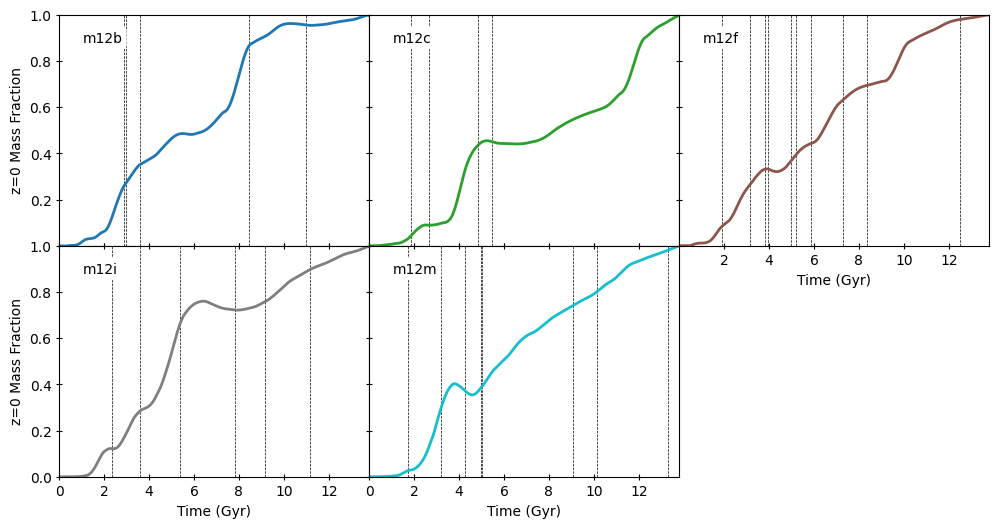

In [4]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i", "m12i", "m12i", "m12i", "m12i"]
# sim_lst = ["m12i", "m12f"]

# sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/One_Touch/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

nrows = 2
ncols = 3

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=False, sharex=False)
plt.subplots_adjust(hspace=0, wspace=0)

xticks = [0, 2, 4, 6, 8, 10, 12]
yticks = [0, 0.2, 0.4, 0.6, 0.8, 1]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

for i, ax in enumerate(axs.flatten()):
    if i == len(sim_lst):
        ax.axis("off")
        continue
    sim = sim_lst[i]

    mass_ratio_lst, time_lst, acc_dict = return_mass_plot(sim, sim_dir, smoothing=True)

    ax.plot(time_lst, mass_ratio_lst, c=colors[i], lw=2)

    for grp in acc_dict:
        ax.plot([acc_dict[grp], acc_dict[grp]], [0, 1], c="k", ls="--", lw=0.5, zorder=0)

    ax.set_xlim(0, np.max(time_lst))
    ax.set_ylim(0, 1)

    # ax.text(
    #     0.075,
    #     0.9,
    #     sim,
    #     horizontalalignment="left",
    #     verticalalignment="center",
    #     transform=ax.transAxes,
    #     fontsize=10,
    # )

    ax.text(
        0.075,
        0.9,
        sim,
        horizontalalignment="left",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",  # background color
            edgecolor="none",  # no border
            boxstyle="round,pad=0.3",
        ),
    )

    if (i == 0) or (i == 3):
        ax.set_ylabel("z=0 Mass Fraction")

        if i == 0:
            ax.set_yticks(yticks[1:])

    else:
        ax.set_yticklabels([])

    if i < 2:
        ax.set_xticklabels([])

    if i == 2:
        ax.set_xticks(xticks[1:])

    if i < 3:
        ax.tick_params(axis="x", which="major", direction="inout", bottom=True, top=False, length=4)
    else:
        ax.tick_params(axis="x", which="major", direction="inout", bottom=True, top=True, length=4)

    ax.tick_params(axis="y", which="major", direction="inout", left=True, right=False, length=4)

    if i in [2, 3, 4]:
        ax.set_xlabel("Time (Gyr)")

    kappa_dict = {
        "m12b": {"kappa_015": 4.6, "kappa_02": 5.3, "kappa_04": 6.9},
        "m12c": {"kappa_015": 6.6, "kappa_02": 6.8, "kappa_04": 8.5},
        "m12f": {"kappa_015": 3.6, "kappa_02": 3.85, "kappa_04": 6.9},
        "m12i": {"kappa_015": 6.43, "kappa_02": 6.6, "kappa_04": 8.4},
        "m12m": {"kappa_015": 3.4, "kappa_02": 3.56, "kappa_04": 4.0},
    }

    kap02 = kappa_dict[sim_lst[i]]["kappa_02"]
    kap04 = kappa_dict[sim_lst[i]]["kappa_04"]

    # ax.plot([kap02, kap02], [0, 1], c="r", ls="--", lw=0.75, zorder=0)
    # ax.plot([kap04, kap04], [0, 1], c="r", ls="--", lw=0.75, zorder=0)

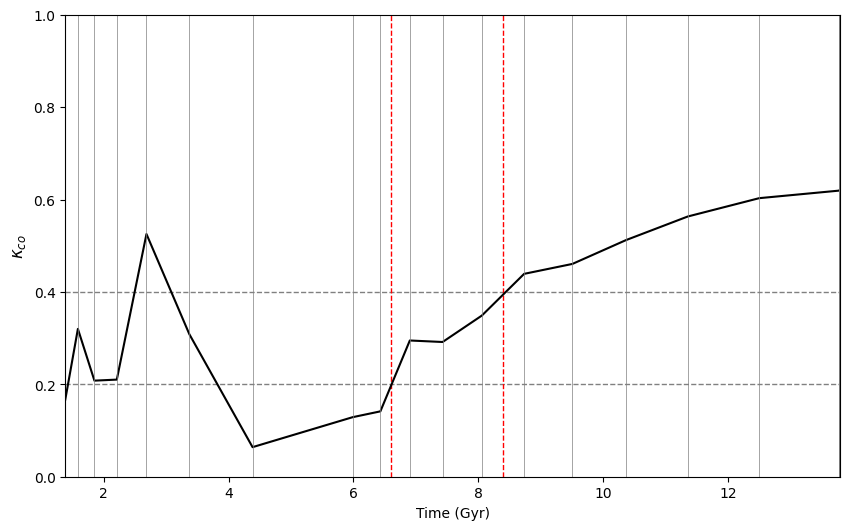

In [10]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_lst = ["m12i"]

# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
# sim_dir = "/Volumes/My_passport_for_Mac/simulations/"
# sim_dir = "/Volumes/One_Touch/simulations/"

plt.figure(figsize=(10, 6))

# cmap = plt.get_cmap("cool")
# cmap = plt.get_cmap("jet")
cmap = plt.get_cmap("tab10")

colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

for i, sim in enumerate(sim_lst):
    # currently set to kappa_co of stars and cold gas
    time_lst, kappa_co_lst = return_kappa_co(sim, sim_dir, spec_type="sg")
    # kappa_co_lst = savgol_filter(kappa_co_lst, window_length=10, polyorder=5)
    # plt.plot(time_lst, kappa_co_lst, c=colors[i], lw=1.5, label=sim)
    plt.plot(time_lst, kappa_co_lst, c="k", lw=1.5, label=sim)

# plt.legend(loc="lower right")

plt.xlim(np.min(time_lst), np.max(time_lst))
plt.ylim(0, 1)

plt.plot([np.min(time_lst), np.max(time_lst)], [0.4, 0.4], c="grey", ls="--", lw=1, zorder=0)
plt.plot([np.min(time_lst), np.max(time_lst)], [0.2, 0.2], c="grey", ls="--", lw=1, zorder=0)
# plt.plot([np.min(time_lst), np.max(time_lst)], [0.15, 0.15], c="grey", ls="--", lw=1, zorder=0)

################################################################################################

kappa_dict = {
    "m12b": {"kappa_015": 4.6, "kappa_02": 5.3, "kappa_04": 6.9},
    "m12c": {"kappa_015": 6.6, "kappa_02": 6.8, "kappa_04": 8.5},
    "m12f": {"kappa_015": 3.6, "kappa_02": 3.85, "kappa_04": 6.9},
    "m12i": {"kappa_015": 6.43, "kappa_02": 6.6, "kappa_04": 8.4},
    "m12m": {"kappa_015": 3.4, "kappa_02": 3.56, "kappa_04": 4.0},
}

# kapp_015 = kappa_dict[sim]["kappa_015"]
kapp_02 = kappa_dict[sim]["kappa_02"]
kapp_04 = kappa_dict[sim]["kappa_04"]

# plt.plot([kapp_015, kapp_015], [0, 1], c="g", ls="--", lw=1, zorder=0)
plt.plot([kapp_02, kapp_02], [0, 1], c="r", ls="--", lw=1, zorder=0)
plt.plot([kapp_04, kapp_04], [0, 1], c="r", ls="--", lw=1, zorder=0)

plt.xlabel("Time (Gyr)")
plt.ylabel(r"$\kappa_{co}$", fontsize=12)

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

for time in pub_snaps["time_Gyr"]:
    plt.plot([time, time], [0, 1], c="grey", lw=0.5)

In [1]:
it_min = 0
it_max = 100

sim = "m12m"

proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

count = []
for it in range(it_min, it_max + 1):
    it_id = gc_utils.iteration_name(it)
    snp_dat = proc_data[it_id]["snapshots"]["snap600"]
    count.append(len(snp_dat["gc_id"][()]))

np.average(count)

NameError: name 'sim_dir' is not defined

In [51]:
proc_data.close()

In [57]:
sim = "m12m"
sim_dir = "/Volumes/Expansion/simulations/"

# halt = gc_utils.get_halo_tree(sim, sim_dir, species="star")
# halt = gc_utils.get_halo_tree(sim, sim_dir)

In [ ]:
# halt["tid"][0], 53854632

53854632

In [ ]:
# sim_code_file = sim_dir + "simulation_codes.json"
# with open(sim_code_file, "r") as file:
#     sim_codes = json.load(file)
# main_halo = sim_codes[sim]["halo"]

# hidx = np.where(halt["tid"] == main_halo)[0][0]
# halt["star.radius.90"][hidx]

10.622965

In [39]:
# halt["star.mass"][hidx] * 10**-10

In [58]:
import halo_analysis as halo

fire_dir = sim_dir + sim + "/" + sim + "_res7100/"
hal = halo.io.IO.read_catalogs("redshift", 0, fire_dir, species="star")

In [59]:
hidx = hal["host.index"][0]
hal.prop("star.radius.90")[hidx]

12.621887

In [60]:
hal["tree.index"][hidx]

1792077